In [2]:
import pandas as pd
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [3]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)
plt.rcParams['font.family'] = 'sans-serif'

In [9]:
con = duckdb.connect()
query_sales = """
    SELECT 
        -- DATE_TRUNC sẽ gom tất cả các ngày trong tháng về ngày mùng 1
        DATE_TRUNC('month', Date) AS YearMonth,
        SUM(Revenue) AS Revenue,
        SUM(Revenue) - SUM(COGS) AS Profit
    FROM '../../../data/analytical/sales.csv'
    GROUP BY YearMonth
    ORDER BY YearMonth
"""
monthly_sales = con.execute(query_sales).df()
monthly_sales

,YearMonth,Revenue,Profit
0,2012-07-01,1.304068e+08,27890299.64
1,2012-08-01,1.590892e+08,33503933.88
2,2012-09-01,1.293071e+08,26710979.00
3,2012-10-01,1.101857e+08,22130889.42
4,2012-11-01,9.818630e+07,20366217.83
...,...,...,...
121,2022-08-01,1.135429e+08,19509565.13
122,2022-09-01,8.576429e+07,7369044.32
123,2022-10-01,7.519445e+07,13224558.51
124,2022-11-01,5.220008e+07,5102060.14


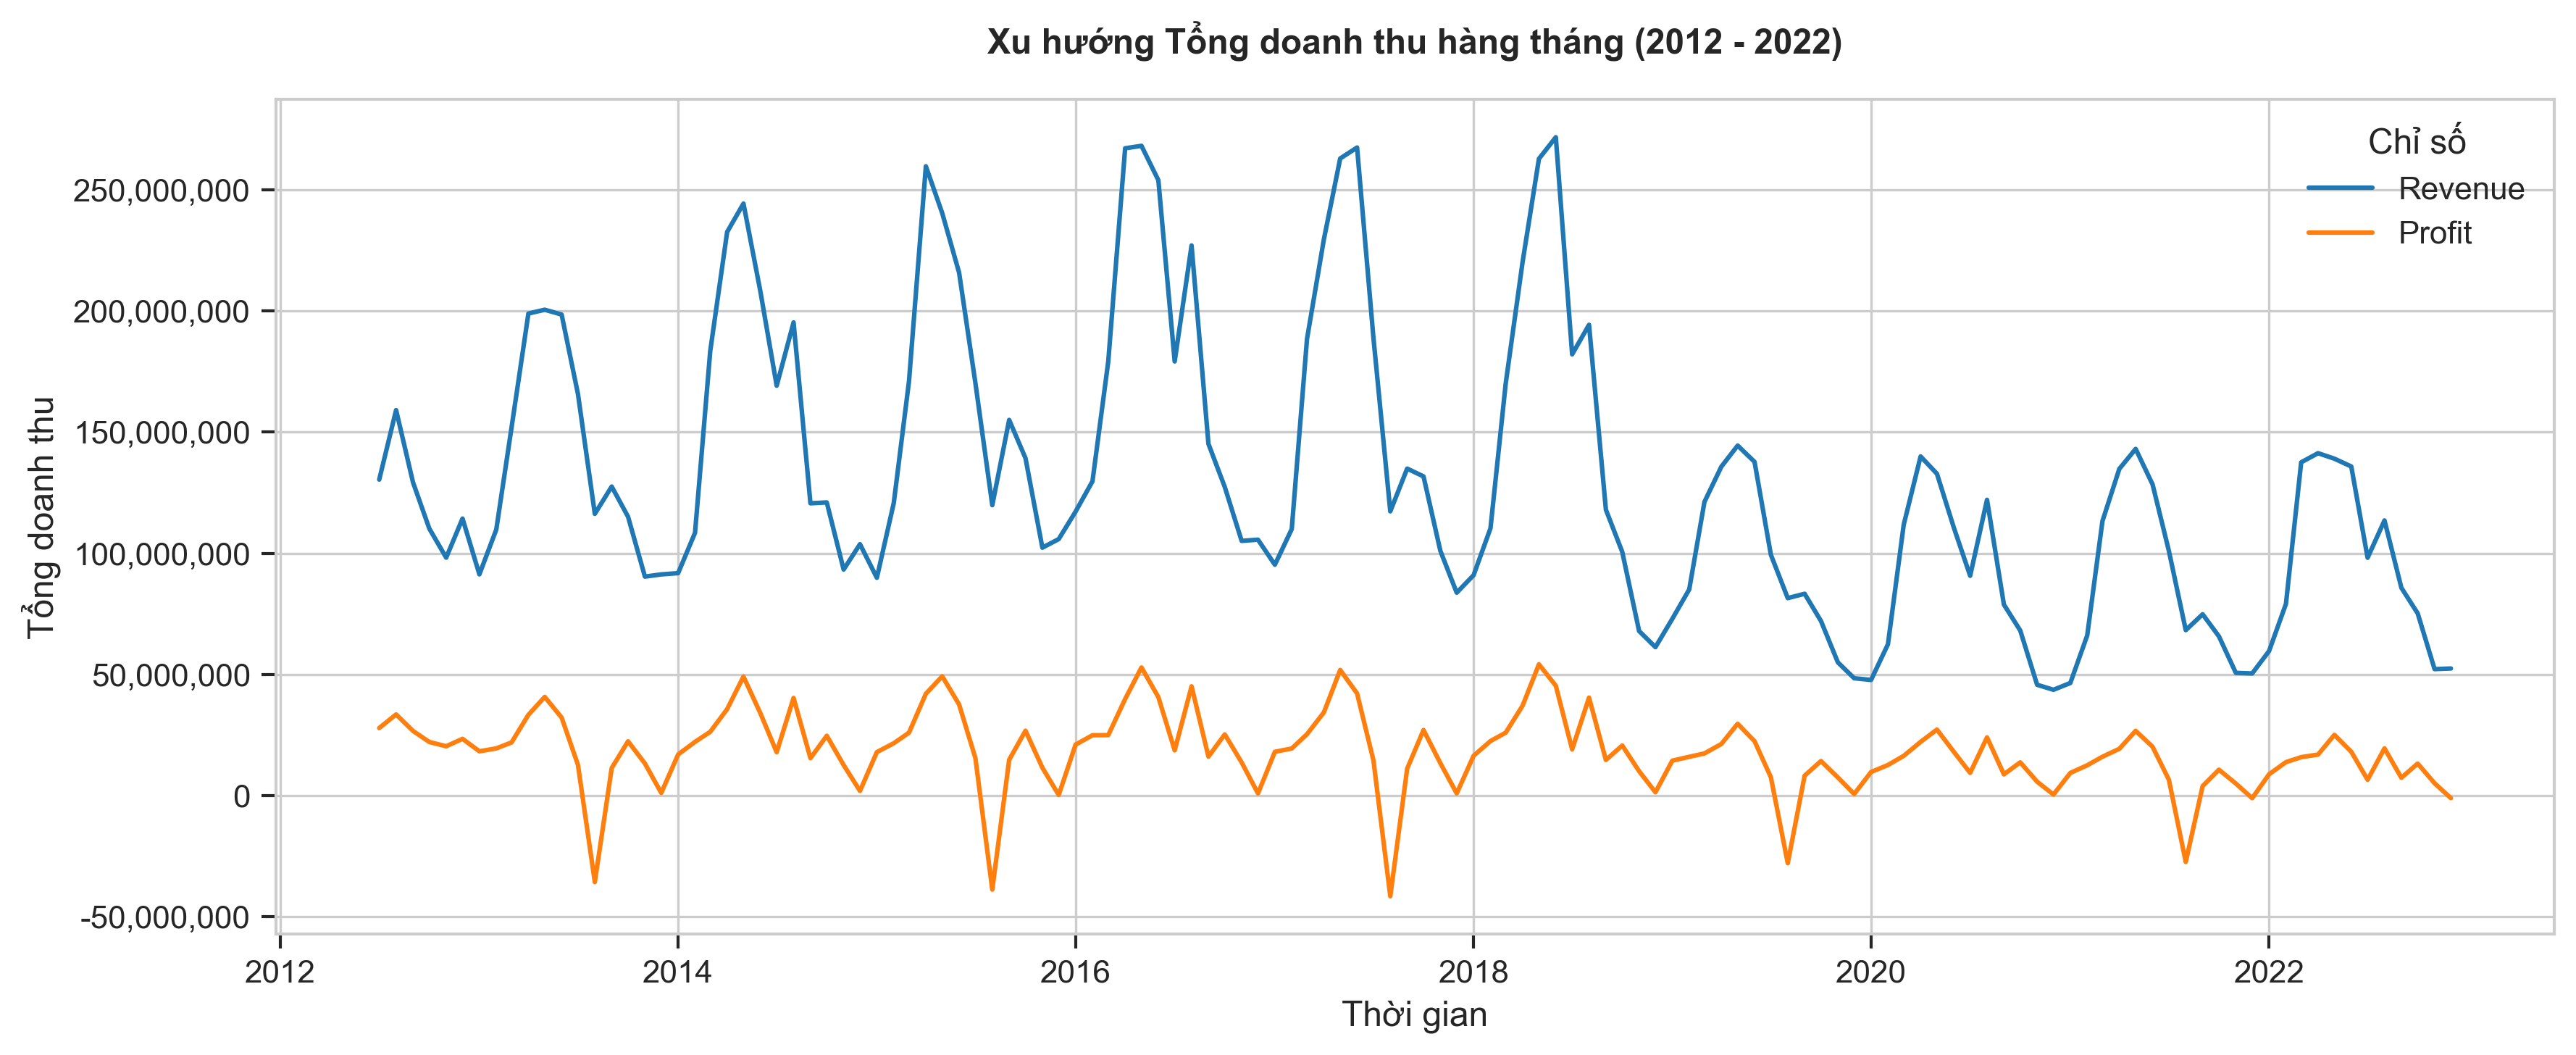

In [14]:
fig, ax = plt.subplots(figsize=(12, 5), dpi=300)

df_melted = monthly_sales.melt(
    id_vars=['YearMonth'], 
    value_vars=['Revenue', 'Profit'], 
    var_name='Chỉ số', 
    value_name='Giá trị'
)

sns.lineplot(
    data=df_melted, 
    x='YearMonth', 
    y='Giá trị', 
    hue='Chỉ số',
    color='#2c3e50', 
    linewidth=1.5,
    ax=ax
)
ax.set_title('Xu hướng Tổng doanh thu hàng tháng (2012 - 2022)', fontweight='bold', pad=15)
ax.set_xlabel('Thời gian')
ax.set_ylabel('Tổng doanh thu')

# Định dạng trục Y hiển thị số có dấu phẩy (vd: 1,000,000) thay vì e+09
def millions_formatter(x, pos):
    return f'{x:,.0f}'
ax.yaxis.set_major_formatter(FuncFormatter(millions_formatter))

plt.tight_layout()

# Lưu file vector nét căng cho báo cáo LaTeX
# plt.savefig('revenue_over_time.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [12]:
query_top_months = """
    -- Bước 1: Tính tổng Doanh thu và Gross Profit cho TỪNG tháng của TỪNG năm
    WITH MonthlyStats AS (
        SELECT 
            YEAR(Date) AS sales_year,
            MONTH(Date) AS sales_month,
            SUM(Revenue) AS total_revenue,
            SUM(Revenue - COGS) AS total_gross_profit
        FROM '../../../data/analytical/sales.csv'
        GROUP BY sales_year, sales_month
    ),

    -- Bước 2: Dùng Hàm cửa sổ (ROW_NUMBER) để xếp hạng các tháng trong nội bộ từng năm
    RankedStats AS (
        SELECT 
            sales_year,
            sales_month,
            total_revenue,
            total_gross_profit,
            -- Xếp hạng tháng theo doanh thu (1 là cao nhất)
            ROW_NUMBER() OVER(PARTITION BY sales_year ORDER BY total_revenue DESC) AS rev_rank,
            -- Xếp hạng tháng theo lợi nhuận (1 là cao nhất)
            ROW_NUMBER() OVER(PARTITION BY sales_year ORDER BY total_gross_profit DESC) AS profit_rank
        FROM MonthlyStats
    )

    -- Bước 3: Lọc ra các tháng Hạng 1 và ghép chúng lại với nhau theo năm
    SELECT 
        r_rev.sales_year AS "year",
        
        r_rev.sales_month AS "rev_best_month",
        CAST(r_rev.total_revenue AS BIGINT) AS "revenue",
        
        r_prof.sales_month AS "profit_best_month",
        CAST(r_prof.total_gross_profit AS BIGINT) AS "profit",
        
        (profit * 1.0 / revenue) AS profit_margin
        
    FROM RankedStats r_rev
    -- Nối chính cái bảng RankedStats lại với nhau để ghép cột
    JOIN RankedStats r_prof ON r_rev.sales_year = r_prof.sales_year 
        AND r_prof.profit_rank = 1 -- Lọc lấy tháng có lợi nhuận top 1
    WHERE r_rev.rev_rank = 1       -- Lọc lấy tháng có doanh thu top 1
    ORDER BY year ASC;
"""

# Thực thi và hiển thị kết quả
df_top_months = duckdb.connect().execute(query_top_months).df()
df_top_months

,year,rev_best_month,revenue,profit_best_month,profit,profit_margin
0,2012,8,159089240,8,33503934,0.210598
1,2013,5,200500109,5,40740956,0.203197
2,2014,5,244309542,5,49115634,0.201039
3,2015,4,259694425,5,49244620,0.189625
4,2016,5,268131884,5,52882578,0.197226
5,2017,6,267433342,5,51840650,0.193845
6,2018,6,271674172,5,54184728,0.199447
7,2019,5,144443148,5,29649972,0.205271
8,2020,4,139960651,5,27254495,0.194730
9,2021,5,143070695,5,26731170,0.186839


`=> Bán nhiều chưa chắc đã lời nhiều: 2015, 2017, 2018, 2020, 2022`

`Tháng 5 mang lại lợi nhuận cao nhất`

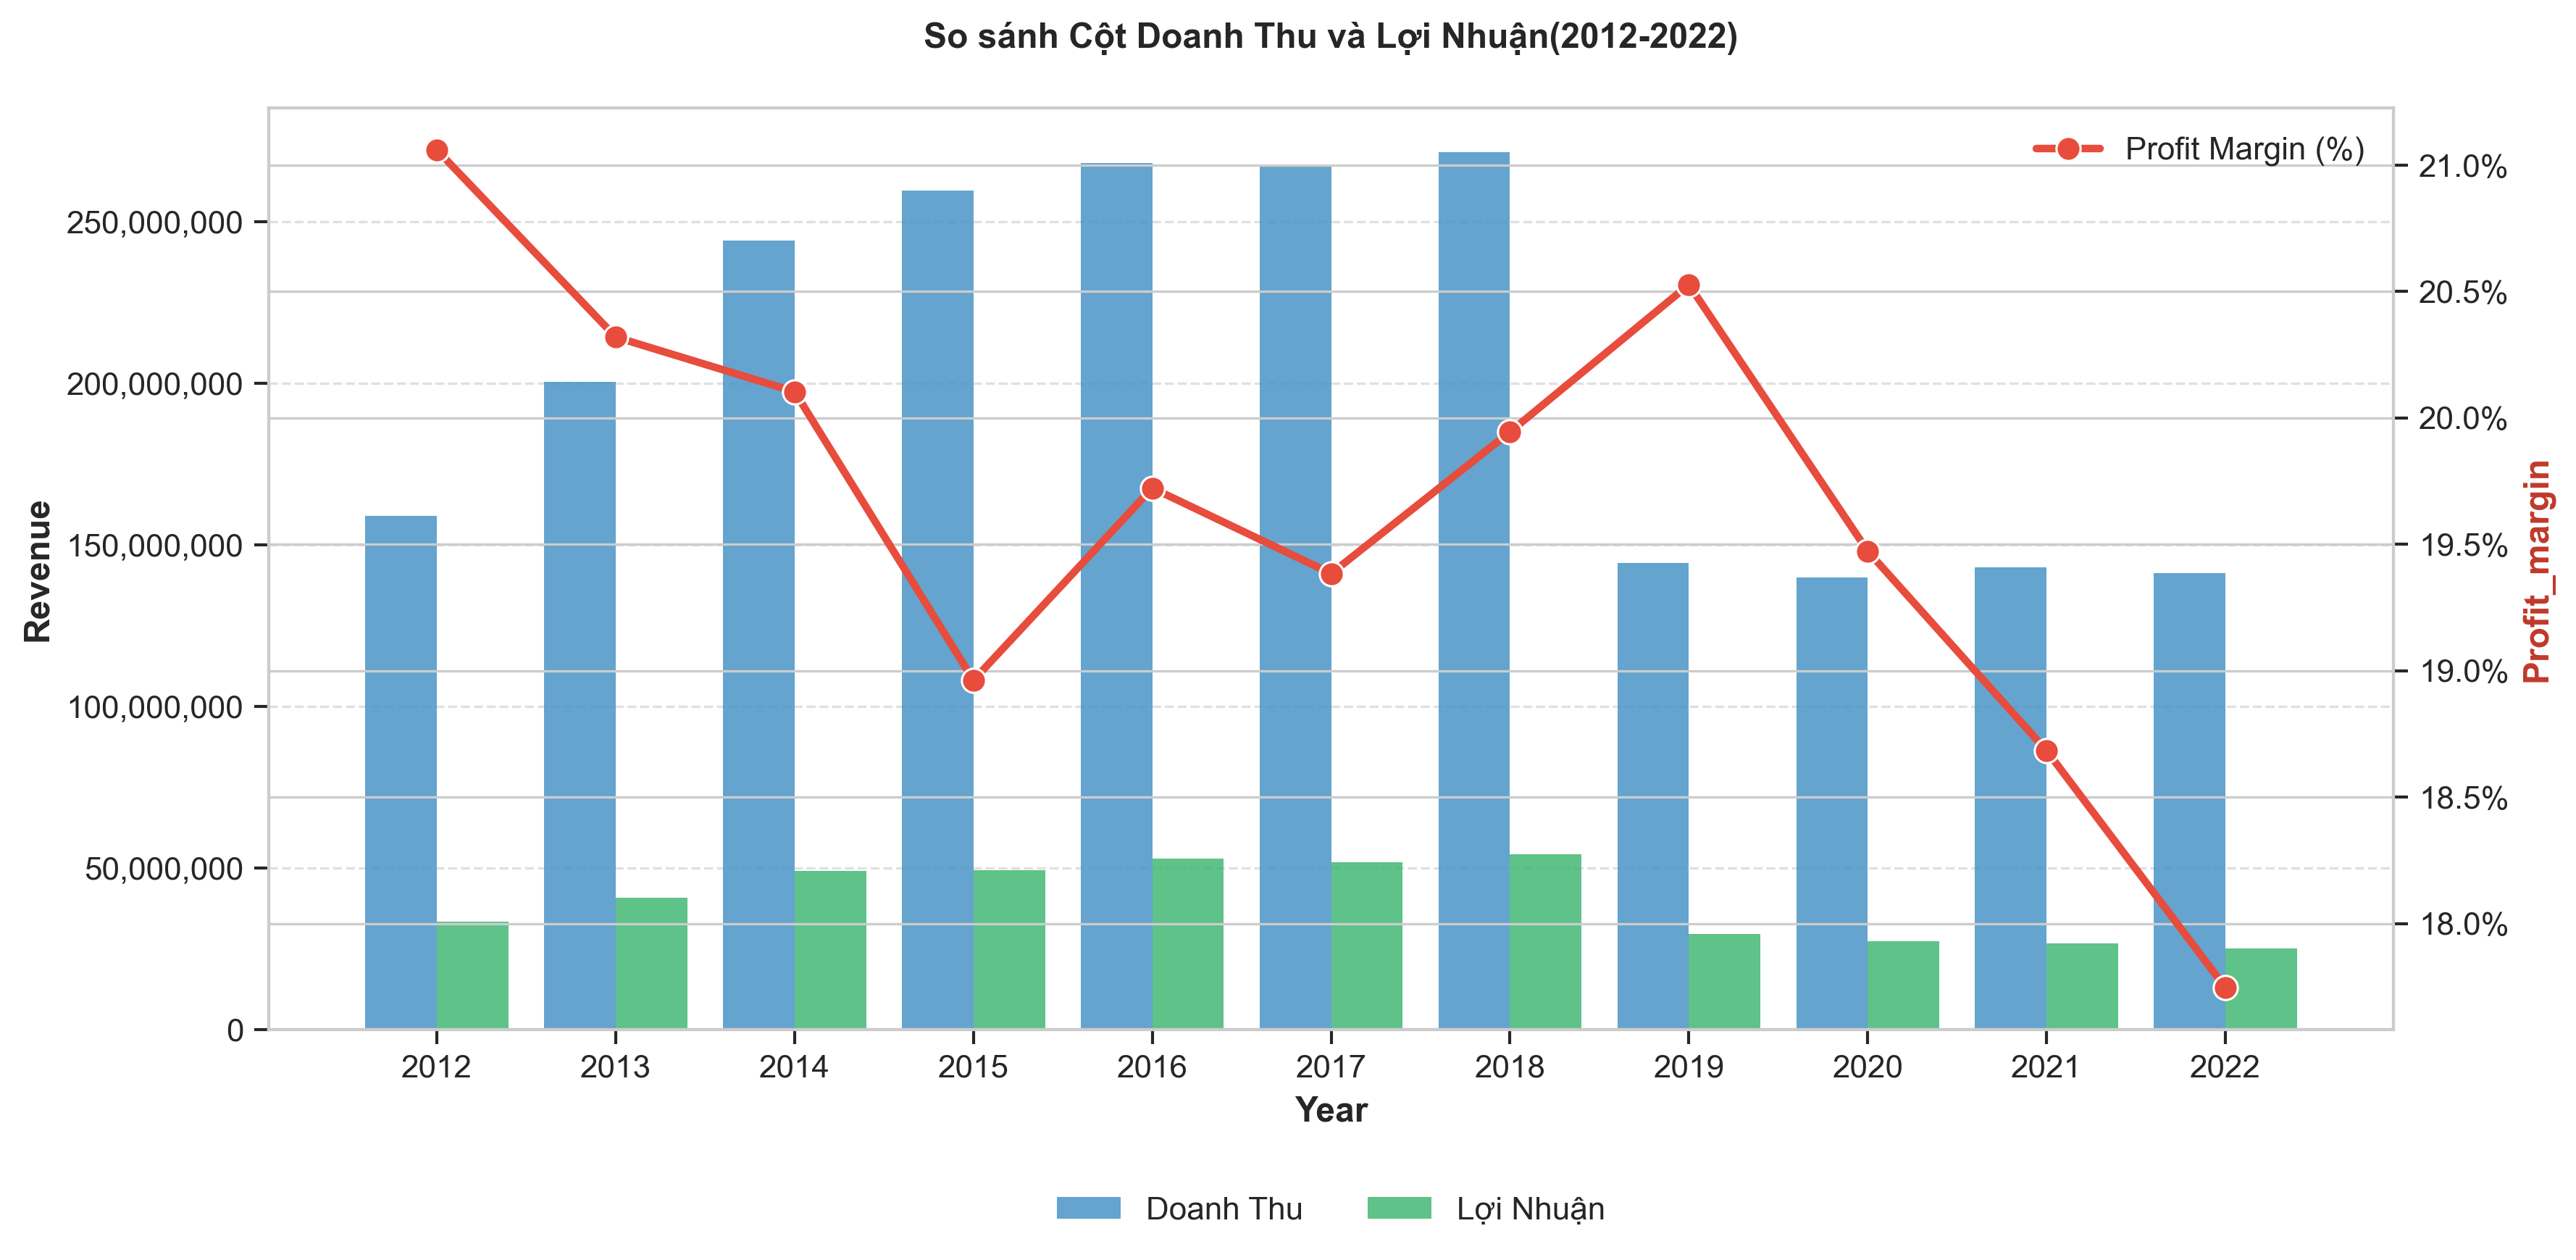

In [13]:
# Ép bảng dữ liệu (df_result) thành dạng dài để Seaborn dễ vẽ Grouped Bar
df_melted = df_top_months.melt(
    id_vars=['year'], 
    value_vars=['revenue', 'profit'], 
    var_name='Chỉ số', 
    value_name='Giá trị'
)

# 3. Khởi tạo Figure
fig, ax = plt.subplots(figsize=(12, 6), dpi=300)

# 4. Vẽ biểu đồ cột ghép (Grouped Bar Chart)
sns.barplot(
    data=df_melted, 
    x='year', 
    y='Giá trị', 
    hue='Chỉ số',             # Hue chính là chìa khóa để ghép 2 cột cạnh nhau
    palette=['#3498db', '#2ecc71'], # Xanh lam cho Doanh thu, Xanh lục cho Lợi nhuận
    alpha=0.85,
    ax=ax
)

# 5. Tinh chỉnh hiển thị
ax.set_title('So sánh Cột Doanh Thu và Lợi Nhuận(2012-2022)', fontweight='bold', pad=20)
ax.set_xlabel('Year', fontweight='bold')
ax.set_ylabel('Revenue', fontweight='bold')

ax2 = ax.twinx() # Tạo trục Y thứ 2 dùng chung trục X
sns.lineplot(
    data=df_top_months, 
    x=df_top_months.index, 
    y='profit_margin', 
    color='#e74c3c', 
    marker='o', 
    linewidth=2.5,
    markersize=8,
    ax=ax2,
    label='Profit Margin (%)'
)
ax2.set_ylabel('Profit_margin', color='#c0392b', fontweight='bold')
ax2.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f'{y*100:.1f}%'))

# Format trục Y hiển thị số đầy đủ có dấu phẩy
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:,.0f}'))

# Tinh chỉnh Legend nằm gọn gàng dưới đáy (tránh đè vào cột)
handles, labels = ax.get_legend_handles_labels()
# Đổi tên nhãn tiếng Anh sang tiếng Việt cho báo cáo
labels_vi = ['Doanh Thu', 'Lợi Nhuận'] 
ax.legend(
    handles, 
    labels_vi, 
    loc='upper center', 
    bbox_to_anchor=(0.5, -0.15), 
    ncol=2, 
    frameon=False
)

# Thêm lưới ngang cho dễ so sánh độ cao
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
# plt.savefig('revenue_vs_profit_grouped.pdf', format='pdf', bbox_inches='tight')
plt.show()